# Explainable AI & Predictive Modeling with SHAP

**Roxanne Lyle**  
Portfolio Case Study | Python • scikit-learn • Random Forest • SHAP

---

## Case Study Purpose

This project evaluates a nonlinear Random Forest regression model and then audits its behavior with SHAP. The workflow combines predictive validation, residual analysis, global and local explanations, comparison with alternative importance methods, feature-dependence analysis, and a focused explanation-stability test.

The analysis is guided by four questions:

1. **Does the fitted Random Forest outperform simple predictive alternatives on the executed evaluation?**
2. **What do SHAP values reveal globally and locally about this fitted model?**
3. **How stable and method-dependent are the explanations?**
4. **What conclusions are supported by the evidence, and what would require additional validation before real-world use?**

> **Evidence standard:** Executed results are reported as observations. Interpretation is kept separate from causal claims, fairness claims, and deployment claims. SHAP attribution is treated as evidence about the fitted model's behavior, not as proof that the model or its decisions are correct.

## Case Study Roadmap

| Stage | Purpose |
|---|---|
| **Sections 1–3** | Establish the SHAP/Shapley foundation, reproducibility record, dataset scope, and data-quality checks |
| **Sections 4–6** | Validate predictive performance using baselines, held-out metrics, cross-validation, and error analysis |
| **Sections 7–10** | Calculate and interpret global, directional, dependence-based, and local SHAP explanations |
| **Sections 11–13** | Compare alternative importance definitions and test feature dependence and seed stability |
| **Sections 14–15** | Evaluate transparency, practical use, governance, advantages, limitations, and method suitability |
| **Sections 16–18** | Consolidate executed evidence, synthesize conclusions, and document engineering takeaways |

### Analytical Sequence

**Model validity → SHAP calculation → global explanation → feature behavior → local explanation → method comparison → dependence/stability audit → practical and governance interpretation**

The sequence is deliberate: the model is evaluated before its explanations are treated as meaningful evidence.

# 1. From Shapley Values to SHAP

Shapley values originated in cooperative game theory as a principled way to distribute a coalition's total value among participating players according to their average marginal contributions across possible coalitions (Shapley, 1953). For player $i$, the Shapley value can be written as:

$$
\phi_i(v)=
\sum_{S\subseteq N\setminus\{i\}}
\frac{|S|!\,(M-|S|-1)!}{M!}
\left[v(S\cup\{i\})-v(S)\right]
$$

where:

- $N$ is the full set of $M$ players;
- $S$ is a coalition that does not yet contain player $i$;
- $v(S)$ is the value assigned to coalition $S$;
- $v(S\cup\{i\})-v(S)$ is player $i$'s marginal contribution; and
- the factorial weighting averages that marginal contribution across possible coalition orders.

SHAP adapts this game-theoretic logic to machine learning. **Features act as players, the model prediction is the quantity being explained, and a feature's SHAP value represents its attributed contribution to moving the model output away from a reference value** (Lundberg & Lee, 2017). The precise meaning of a feature being "absent" depends on the explainer's assumptions about the background distribution and feature dependence, so SHAP values should be interpreted in the context of the explainer configuration.

For an additive SHAP explanation of one prediction $f(x)$:

$$
f(x)=\mathbb{E}[f(X)] + \sum_{j=1}^{M}\phi_j
$$

where $\mathbb{E}[f(X)]$ is the explainer's baseline and $\phi_j$ is feature $j$'s contribution. A positive SHAP value pushes the model output above the baseline, a negative value pushes it below the baseline, and the magnitude represents the size of the attributed contribution for that prediction.

The game-theoretic foundation is important because Shapley values are associated with several allocation principles. **Efficiency** requires the attributed contributions to account for the total value being distributed; **symmetry** assigns equal credit to players with equivalent marginal contributions; the **dummy/null-player principle** gives zero credit to a player that contributes nothing; and **additivity** preserves the allocation structure when games are combined (Shapley, 1953). Lundberg and Lee (2017) connect SHAP to additive feature-attribution methods and identify properties including local accuracy and consistency. For supported tree ensembles, TreeExplainer provides an efficient tree-specific implementation, making it particularly suitable for the Random Forest used here (Lundberg et al., 2020).

The additive/local-accuracy idea is tested later in Section 7.1 by reconstructing the Random Forest predictions from the SHAP baseline and feature contributions rather than assuming the property holds in the executed result.

### Boundary of Interpretation

A SHAP value explains **the fitted model's behavior under a particular explainer formulation**. It does **not** establish that changing a feature would causally change the real-world outcome by the SHAP amount. Feature dependence can also affect how attribution is distributed among predictors (Aas et al., 2021). This notebook therefore treats SHAP as a model-auditing and interpretation tool—not as a causal estimator, fairness test, or guarantee of trustworthy deployment.

# 2. Python Environment and Reproducibility

The workflow uses SHAP, pandas, NumPy, scikit-learn, and Matplotlib. Additional scikit-learn utilities are used for baseline comparison, predictive validation, error analysis, feature-importance comparison, and explanation robustness.

A fixed random seed is used wherever randomness is introduced, and package versions are printed with the executed results. This makes the computational environment part of the evidence record. Reproducibility here refers to the ability to reproduce the executed workflow under the same data, software, and documented randomization choices; it does **not** imply that the findings will generalize to different populations, locations, or time periods.

In [1]:
# Install SHAP in Colab if needed.
%pip -q install shap

In [2]:
# Required libraries
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Additional evaluation and comparison tools
import sklearn
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from IPython.display import display, Markdown

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Reproducibility record")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"SHAP version: {shap.__version__}")

Reproducibility record
NumPy version: 2.1.3
pandas version: 2.2.3
scikit-learn version: 1.6.1
SHAP version: 0.52.0


### Reproducibility Note

The primary Random Forest uses `random_state=42`. Cross-validation and robustness extensions also use documented seeds. The executed environment recorded **NumPy 2.1.3, pandas 2.2.3, scikit-learn 1.6.1, and SHAP 0.52.0**. Because numerical behavior and plotting conventions can change across software versions, retaining this environment record strengthens reproducibility without implying external validity.

# 3. Load the California Housing Dataset

The California Housing dataset contains **20,640 census block groups and eight numeric predictive features**. The target is median house value expressed in units of **\$100,000**. The dataset was derived from the 1990 U.S. Census, so it is appropriate for an academic regression and explainability exercise but should not be treated as a representation of current California housing conditions (Pace & Barry, 1997; Scikit-learn developers, n.d.).

The predictive features are:

- `MedInc` — median income in the block group
- `HouseAge` — median house age
- `AveRooms` — average rooms per household
- `AveBedrms` — average bedrooms per household
- `Population` — block-group population
- `AveOccup` — average household occupancy
- `Latitude` — block-group latitude
- `Longitude` — block-group longitude

The scikit-learn loading approach is preserved below, followed by explicit checks that the expected rows, columns, and feature names were loaded.

In [3]:
# Step 2:
# Load the California Housing dataset
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
display(X.head())

Feature matrix shape: (20640, 8)
Target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
# Verify that the expected scikit-learn dataset was loaded.
expected_features = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude"
]

assert X.shape[1] == 8, f"Expected 8 predictors, found {X.shape[1]}."
assert list(X.columns) == expected_features, "Unexpected feature names or order."
assert len(X) == len(y), "Feature and target row counts do not match."

print("Dataset identity checks passed.")
print(f"Rows loaded: {len(X):,}")
print(f"Predictors: {', '.join(X.columns)}")

Dataset identity checks passed.
Rows loaded: 20,640
Predictors: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude


## 3.1 Data Quality and Scope Audit

Before modeling, the dataset is checked for missing and non-finite values, duplicate feature rows, target range, and repeated maximum target values. No observation is removed merely because it appears unusual. A repeated maximum is first treated as an observed data pattern and then carried forward as a limitation to examine during error analysis.

This matters for explainability because SHAP can faithfully explain patterns learned from problematic or unrepresentative data. **Explanation quality does not substitute for data-quality review.**

In [5]:
y_series = pd.Series(y, name="MedHouseVal")

quality_audit = pd.DataFrame({
    "Check": [
        "Rows",
        "Predictive features",
        "Missing feature values",
        "Missing target values",
        "Non-finite feature values",
        "Non-finite target values",
        "Duplicate feature rows",
        "Minimum target",
        "Maximum target",
        "Rows equal to observed maximum target"
    ],
    "Observed value": [
        len(X),
        X.shape[1],
        int(X.isna().sum().sum()),
        int(y_series.isna().sum()),
        int((~np.isfinite(X.to_numpy())).sum()),
        int((~np.isfinite(y_series.to_numpy())).sum()),
        int(X.duplicated().sum()),
        float(y_series.min()),
        float(y_series.max()),
        int(np.isclose(y_series, y_series.max()).sum())
    ]
})

display(quality_audit)

print("\nTarget summary (units of $100,000):")
display(y_series.describe().to_frame())

,Check,Observed value
0,Rows,20640.00000
1,Predictive features,8.00000
2,Missing feature values,0.00000
3,Missing target values,0.00000
4,Non-finite feature values,0.00000
5,Non-finite target values,0.00000
6,Duplicate feature rows,0.00000
7,Minimum target,0.14999
8,Maximum target,5.00001
9,Rows equal to observed maximum target,992.00000



Target summary (units of $100,000):


,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


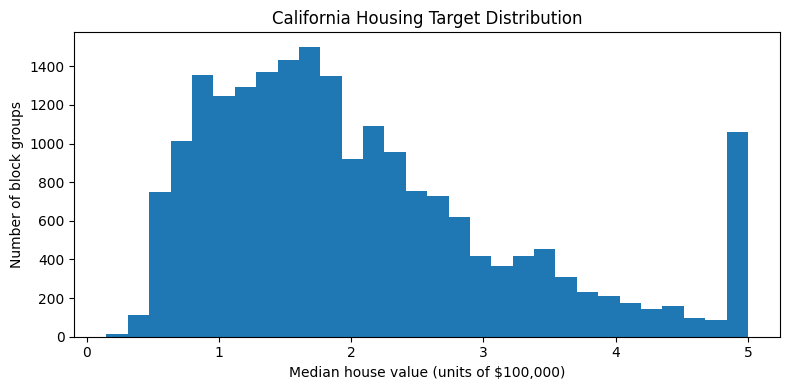

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(y_series, bins=30)
plt.xlabel("Median house value (units of $100,000)")
plt.ylabel("Number of block groups")
plt.title("California Housing Target Distribution")
plt.tight_layout()
plt.show()

### Executed Data-Audit Interpretation

The dataset loaded as expected with **20,640 observations and eight predictors**, and the audit found **no missing values, non-finite values, or duplicate feature rows**. No observations were removed, so the modeling workflow retained the full project dataset. The target ranged from **0.14999 to 5.00001** in units of \$100,000, with a mean of **2.0686** and a median of **1.7970**. The histogram is right-skewed and shows a pronounced concentration at the upper end: **992 observations, about 4.8% of the dataset, equal the observed maximum target value**.

That repeated maximum is analytically important. It is treated here as an **observed ceiling-like pattern**, not automatically as an error and not as proof of a particular data-collection mechanism. Because many observations share the same upper target value, the later residual and quartile analyses explicitly examine whether the model behaves differently for high-value observations.

**Interpretive boundary:** the clean data-quality audit supports proceeding with the assigned modeling workflow, but it does not establish that the data are current, representative of present-day California housing, or free from historical measurement and aggregation limitations.

# 4. Train/Test Split and Evaluation Framework

The evaluation design uses an **80% training / 20% test split with `random_state=42`**, which is reproduced exactly. The held-out test set is not used to fit the comparison models or generate the cross-validation estimates; it is later used for final predictive evaluation and the explanation/importance analyses.

No hyperparameter tuning is performed because the specified model is a 100-tree Random Forest and the purpose of the project is explainability rather than exhaustive model selection. Three predictive references are used:

1. **Mean Dummy Regressor** — establishes whether the machine-learning models improve on a naive constant prediction.
2. **Linear Regression** — provides a simpler and more intrinsically interpretable functional-form comparison.
3. **Primary Random Forest** — the nonlinear ensemble explained with SHAP.

### Evaluation Metrics

- **MAE** reports average absolute prediction error in the target's units.
- **RMSE** gives greater weight to larger errors and helps reveal substantial misses.
- **R²** measures predictive improvement relative to the test-set mean; it is not causal explanatory power.
- **Five-fold cross-validation mean and standard deviation** provide an additional view of sampling variability within the training data.

Dollar-equivalent errors are calculated by multiplying target-scale errors by \$100,000, consistent with the dataset's target encoding. These values are **not inflation-adjusted to current dollars**.

No arbitrary threshold is used to label performance as "good" or "poor." Performance is interpreted comparatively against the baselines and within the limitations of the evaluation design.

In [7]:
# Step 3:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Training proportion: {len(X_train) / len(X):.2%}")
print(f"Test proportion: {len(X_test) / len(X):.2%}")

Training observations: 16,512
Test observations: 4,128
Training proportion: 80.00%
Test proportion: 20.00%


# 5. Predictive Baselines and Random Forest Performance

A model should be evaluated before its explanations are interpreted. SHAP can explain a weak or misspecified model just as readily as a useful one, so predictive performance and explainability answer different questions.

The Random Forest uses `n_estimators=100` and `random_state=42`. Its held-out performance is compared with both the mean Dummy Regressor and Linear Regression.


In [8]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train, y_train)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Step 4:
# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)
linear_pred = linear_model.predict(X_test)
rf_pred = model.predict(X_test)

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

model_results = []
for model_name, pred in [
    ("Mean Dummy Baseline", dummy_pred),
    ("Linear Regression", linear_pred),
    ("Random Forest", rf_pred),
]:
    mae, rmse, r2 = regression_metrics(y_test, pred)
    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "MAE ($)": mae * 100000,
        "RMSE ($)": rmse * 100000
    })

performance_table = pd.DataFrame(model_results).set_index("Model")
display(performance_table.round({
    "MAE": 4, "RMSE": 4, "R²": 4, "MAE ($)": 0, "RMSE ($)": 0
}))

,MAE,RMSE,R²,MAE ($),RMSE ($)
Model,,,,,
Mean Dummy Baseline,0.9061,1.1449,-0.0002,90607.0,114486.0
Linear Regression,0.5332,0.7456,0.5758,53320.0,74558.0
Random Forest,0.3275,0.5053,0.8051,32754.0,50534.0


In [9]:
rf_mae, rf_rmse, rf_r2 = regression_metrics(y_test, rf_pred)
dummy_mae, dummy_rmse, dummy_r2 = regression_metrics(y_test, dummy_pred)
linear_mae, linear_rmse, linear_r2 = regression_metrics(y_test, linear_pred)

improvement_table = pd.DataFrame({
    "Comparison": [
        "RF vs. mean baseline",
        "RF vs. linear regression"
    ],
    "RMSE reduction": [
        dummy_rmse - rf_rmse,
        linear_rmse - rf_rmse
    ],
    "RMSE reduction (%)": [
        100 * (dummy_rmse - rf_rmse) / dummy_rmse,
        100 * (linear_rmse - rf_rmse) / linear_rmse
    ],
    "R² difference": [
        rf_r2 - dummy_r2,
        rf_r2 - linear_r2
    ]
})

display(improvement_table.round(4))

,Comparison,RMSE reduction,RMSE reduction (%),R² difference
0,RF vs. mean baseline,0.6395,55.860,0.8053
1,RF vs. linear regression,0.2402,32.222,0.2293


### Executed Held-Out Performance Interpretation

On the held-out test set, the Random Forest achieved **MAE = 0.3275**, **RMSE = 0.5053**, and **R² = 0.8051**. In the dataset's encoded target scale, that is approximately **\$32,754 average absolute error** and **\$50,534 RMSE**. Its RMSE was **55.86% lower than the mean Dummy Regressor's RMSE of 1.1449** and **32.22% lower than Linear Regression's RMSE of 0.7456**. The Random Forest also exceeded Linear Regression in R² (**0.8051 vs. 0.5758**), while the mean baseline's **R² = −0.0002** was effectively zero on this test set.

These results justify using the primary Random Forest as the model to explain **within this experiment** because it substantially outperformed both simple references on the executed test split. They do **not** establish that the Random Forest is the best possible California Housing model or that the same performance would hold under different geographic, temporal, or sampling conditions.

# 6. Cross-Validation and Error Analysis

A single train/test split can be sensitive to sampling. Five-fold cross-validation is therefore performed **within the training set**, leaving the held-out test set unchanged for final evaluation.

Cross-validation addresses one form of sampling variability, but these observations are geographically located. Random folds can place nearby block groups in both training and validation data. The procedure therefore does **not** establish performance for genuinely new geographic regions; a stronger deployment-oriented design would also use spatial or geographic holdouts.

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = np.asarray(y_train)[train_idx]
    y_fold_val = np.asarray(y_train)[val_idx]

    for model_name, fold_model in [
        ("Linear Regression", LinearRegression()),
        ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
    ]:
        fold_model.fit(X_fold_train, y_fold_train)
        fold_pred = fold_model.predict(X_fold_val)
        mae, rmse, r2 = regression_metrics(y_fold_val, fold_pred)

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

cv_results = pd.DataFrame(cv_rows)

cv_summary = (
    cv_results.groupby("Model")[["MAE", "RMSE", "R²"]]
    .agg(["mean", "std"])
)

display(cv_summary.round(4))

MAE            RMSE              R²        
                     mean     std    mean     std    mean     std
Model                                                            
Linear Regression  0.5291  0.0105  0.7205  0.0155  0.6115  0.0138
Random Forest      0.3350  0.0058  0.5111  0.0128  0.8045  0.0068

### Executed Cross-Validation Interpretation

Across five training-set folds, the Random Forest produced **mean MAE = 0.3350 ± 0.0058**, **mean RMSE = 0.5111 ± 0.0128**, and **mean R² = 0.8045 ± 0.0068**. Linear Regression produced **mean RMSE = 0.7205 ± 0.0155** and **mean R² = 0.6115 ± 0.0138**.

The Random Forest's cross-validation averages are close to its held-out test results (**RMSE = 0.5053; R² = 0.8051**), and its average cross-validation RMSE remained lower than Linear Regression's. Within this random-fold design, the comparative advantage of the Random Forest therefore persisted across folds rather than appearing only in one favorable test split.

**Boundary of inference:** low variability across these random folds does not establish geographic generalization. A stronger follow-up would repeat validation using geographically separated holdouts and compare whether both predictive performance and SHAP explanations remain stable.

## 6.1 Residual and Error-Pattern Analysis

Overall metrics can hide where a model fails. Residuals are defined as:

$$
r_i = y_i - \hat{y}_i
$$

A positive residual indicates an **underprediction**, while a negative residual indicates an **overprediction**. Errors are also summarized across target-value quartiles so that uneven performance is visible rather than compressed into one average.

In [11]:
error_df = X_test.copy()
error_df["Actual"] = np.asarray(y_test)
error_df["Predicted"] = rf_pred
error_df["Residual"] = error_df["Actual"] - error_df["Predicted"]
error_df["AbsoluteError"] = error_df["Residual"].abs()

error_df["TargetQuartile"] = pd.qcut(
    error_df["Actual"],
    q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
    duplicates="drop"
)

quartile_error = (
    error_df.groupby("TargetQuartile", observed=True)
    .agg(
        n=("AbsoluteError", "size"),
        MAE=("AbsoluteError", "mean"),
        Mean_residual=("Residual", "mean")
    )
)

# Add RMSE per quartile explicitly
quartile_rmse = (
    error_df.groupby("TargetQuartile", observed=True)["Residual"]
    .apply(lambda s: np.sqrt(np.mean(np.square(s))))
    .rename("RMSE")
)
quartile_error = quartile_error.join(quartile_rmse)

display(quartile_error.round(4))

print("Ten largest absolute test errors:")
display(
    error_df[["Actual", "Predicted", "Residual", "AbsoluteError"]]
    .sort_values("AbsoluteError", ascending=False)
    .head(10)
    .round(4)
)

,n,MAE,Mean_residual,RMSE
TargetQuartile,,,,
Q1 (lowest),1032,0.2240,-0.1886,0.3578
Q2,1032,0.2534,-0.1419,0.3855
Q3,1032,0.2927,-0.0698,0.4178
Q4 (highest),1032,0.5401,0.3506,0.7552


Ten largest absolute test errors:


,Actual,Predicted,Residual,AbsoluteError
5887,0.175,3.2208,-3.0458,3.0458
12069,5.000,1.9565,3.0435,3.0435
12389,5.000,2.0256,2.9745,2.9745
20349,1.250,4.0930,-2.8430,2.8430
6688,5.000,2.1940,2.8060,2.8060
19542,4.500,1.6994,2.8006,2.8006
12220,5.000,2.2318,2.7683,2.7683
17306,5.000,2.2443,2.7557,2.7557
4548,0.675,3.4001,-2.7251,2.7251
459,5.000,2.4256,2.5745,2.5745


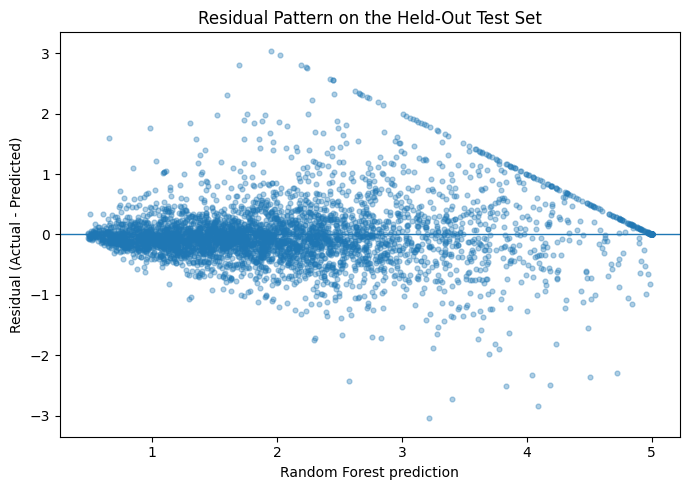

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(rf_pred, error_df["Residual"], alpha=0.35, s=12)
plt.axhline(0, linewidth=1)
plt.xlabel("Random Forest prediction")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Pattern on the Held-Out Test Set")
plt.tight_layout()
plt.show()

### Executed Error-Pattern Interpretation

Prediction error increased across the target quartiles. MAE rose from **0.2240 in Q1** to **0.5401 in Q4**, while RMSE rose from **0.3578 to 0.7552**. Mean residual was negative in Q1 through Q3, indicating average **overprediction** in those ranges, but became **+0.3506 in Q4**, indicating average **underprediction** among the highest-value observations. Q4's MAE was approximately **2.4 times** Q1's MAE.

The residual plot supports the same conclusion. Error spread widens as predicted value increases, and the upper diagonal boundary is consistent with many test observations sharing the dataset's observed maximum target. Several of the ten largest absolute errors occur at or near that maximum. The largest underprediction had an actual value of **5.0000** and a prediction of **1.9565**; the largest absolute error overall was an overprediction, with an actual value of **0.1750** and a prediction of **3.2208**.

This error pattern matters for the SHAP analysis that follows. A SHAP explanation can faithfully decompose **why the model made a prediction** even when that prediction is substantially wrong. Explanation fidelity and predictive accuracy are therefore evaluated separately.

**Specific next validation step:** repeat the residual analysis across multiple resamples and geographically separated holdouts to determine whether upper-range underprediction persists beyond this split.

# 7. Initialize TreeExplainer and Calculate SHAP Values

The project workflow uses `shap.TreeExplainer(model)` and calculates SHAP values for the full held-out test set.

For this regression model, each test observation receives one SHAP value per feature. The explainer's expected value is the baseline from which the feature contributions move the model output. The executed configuration is recorded because both the baseline and the feature-perturbation setting affect how the attributions should be interpreted.

In [13]:
# Step 5:
# Create an explainer object
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

shap_values = np.asarray(shap_values)
expected_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])

print(f"SHAP array shape: {shap_values.shape}")
print(f"Explainer expected value: {expected_value:.6f}")
print(f"Expected value in approximate dollars: ${expected_value * 100000:,.0f}")
print(f"Feature perturbation setting: {getattr(explainer, 'feature_perturbation', 'not exposed')}")

SHAP array shape: (4128, 8)
Explainer expected value: 2.073069
Expected value in approximate dollars: $207,307
Feature perturbation setting: tree_path_dependent


### Executed Explainer Configuration

The executed SHAP array has shape **4,128 × 8**, matching one attribution for each of the eight predictors for every held-out test observation. The TreeExplainer expected value is **2.073069**, approximately **\$207,307 in the dataset's encoded target scale**, and the recorded perturbation setting is **`tree_path_dependent`**.

The expected value is the explainer's reference output for this fitted model; it is not a causal or normative housing benchmark and should not be read as a current-dollar market estimate. The perturbation setting also matters because feature-dependence assumptions can affect how attribution is distributed among correlated predictors.

## 7.1 Additivity / Reconstruction Check

For this additive explanation, the SHAP baseline plus all feature contributions should reconstruct the model output, subject to numerical precision. That property is tested directly rather than assumed.

This check is the executed counterpart to the additive/local-accuracy principle described in Section 1. It evaluates **explanation arithmetic**, not whether the underlying prediction is accurate, fair, causal, or appropriate for deployment.

In [14]:
reconstructed_predictions = expected_value + shap_values.sum(axis=1)
model_predictions_for_check = model.predict(X_test)

reconstruction_error = np.abs(
    reconstructed_predictions - model_predictions_for_check
)

additivity_summary = pd.Series({
    "Mean absolute reconstruction error": reconstruction_error.mean(),
    "Maximum absolute reconstruction error": reconstruction_error.max(),
    "95th percentile reconstruction error": np.percentile(reconstruction_error, 95)
})

display(additivity_summary.to_frame("Observed value"))

,Observed value
Mean absolute reconstruction error,1.823629e-14
Maximum absolute reconstruction error,2.211564e-13
95th percentile reconstruction error,5.151435e-14


### Executed Additivity Interpretation

The reconstruction check produced a **mean absolute error of approximately $1.82 \times 10^{-14}$** and a **maximum error of approximately $2.21 \times 10^{-13}$**. These values are effectively zero at ordinary numerical precision. The executed TreeExplainer attributions therefore reproduce the Random Forest's predictions as the SHAP baseline plus the sum of the eight feature contributions.

This is strong evidence of **additive explanation fidelity for the executed explainer**. It confirms internal consistency between the attributions and the model output. It does **not** mean that the prediction itself is accurate, that the feature contributions are causal, or that the model is fair or deployment-ready. The large-error local cases later in the notebook make this distinction concrete.

# 8. Global SHAP Feature Importance

Global SHAP importance is calculated by averaging the **absolute SHAP magnitude** for each feature across held-out observations. This answers:

> **Which features does this fitted Random Forest rely on most strongly, on average, when its predictions are decomposed by SHAP?**

Absolute values intentionally remove direction, so the bar plot answers **how much**, not whether a feature tends to push predictions upward or downward. It also does **not** identify causal determinants of California housing values.

In [15]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Mean |SHAP|": mean_abs_shap,
        "Mean |SHAP| ($)": mean_abs_shap * 100000
    })
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

shap_importance["Share of total |SHAP| (%)"] = (
    100 * shap_importance["Mean |SHAP|"] / shap_importance["Mean |SHAP|"].sum()
)
shap_importance["Rank"] = np.arange(1, len(shap_importance) + 1)

display(shap_importance.round({
    "Mean |SHAP|": 4,
    "Mean |SHAP| ($)": 0,
    "Share of total |SHAP| (%)": 2
}))

,Feature,Mean |SHAP|,Mean |SHAP| ($),Share of total |SHAP| (%),Rank
0,MedInc,0.5503,55027.0,38.09,1
1,Latitude,0.2608,26083.0,18.06,2
2,AveOccup,0.2376,23756.0,16.44,3
3,Longitude,0.2122,21224.0,14.69,4
4,HouseAge,0.0837,8372.0,5.80,5
5,AveRooms,0.0525,5252.0,3.64,6
6,AveBedrms,0.0280,2795.0,1.94,7
7,Population,0.0195,1950.0,1.35,8


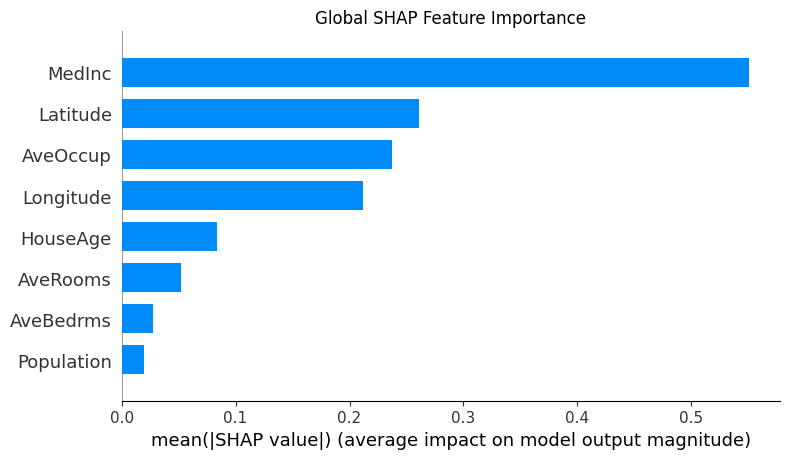

In [16]:
# Step 6:
# Plot the SHAP summary plot for feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

### Executed Global SHAP Importance Interpretation

`MedInc` was the dominant global SHAP feature with mean |SHAP| **0.5503**, equivalent to about **\$55,027 in the encoded target scale**, and represented **38.09%** of total mean absolute attribution. It was followed by `Latitude` (**0.2608; 18.06%**), `AveOccup` (**0.2376; 16.44%**), and `Longitude` (**0.2122; 14.69%**). Together, these four features accounted for approximately **87.3%** of total mean absolute SHAP magnitude. `Population` ranked last at **0.0195 (1.35%)**.

Within this fitted Random Forest, the result shows that median income, geography, and occupancy information contributed most strongly to deviations from the SHAP baseline across the held-out observations. The **38.09% share is a share of model-attribution magnitude**, not the percentage of real-world housing value caused by income. Likewise, the dollar-equivalent SHAP magnitude is a model-output scale, not a causal or current-market effect.

The importance of both `Latitude` and `Longitude` must also be interpreted alongside their strong dependence identified later in the notebook.

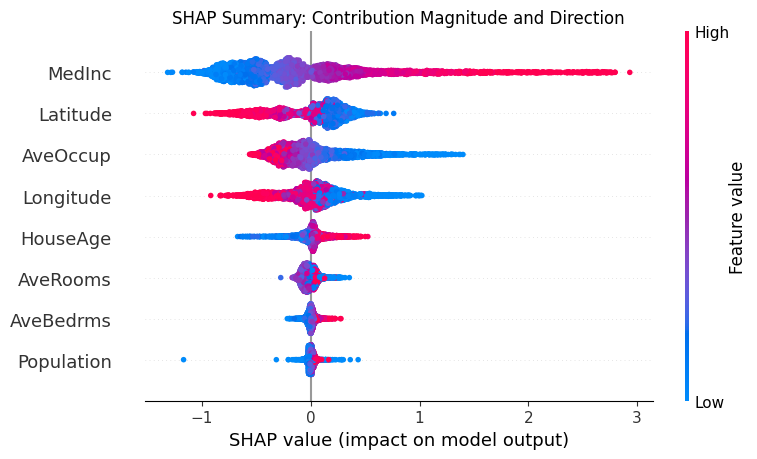

In [17]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary: Contribution Magnitude and Direction")
plt.tight_layout()
plt.show()

### Executed Directional SHAP Interpretation

The SHAP summary distribution adds direction and observation-level variation to the global ranking. The clearest pattern is `MedInc`: **higher median-income values concentrate on the positive SHAP side, while lower values concentrate on the negative side**. The fitted Random Forest therefore generally uses higher `MedInc` values to push predictions above its baseline and lower values to push predictions below it.

`AveOccup` shows a different directional pattern: lower occupancy values appear more often with positive SHAP contributions, while higher occupancy values tend more often toward the negative side. `Latitude` and `Longitude` contribute substantially in both directions, consistent with the model using location nonlinearly rather than as a simple monotonic effect. `HouseAge` shows a smaller directional pattern, while `Population` remains concentrated near zero for most observations.

These are patterns in **model behavior**, not intervention effects. The plot supports describing how the trained Random Forest uses the variables, but it does not establish that changing any one of them would cause the corresponding change in housing value.

# 9. `MedInc` SHAP Dependence Analysis

The assigned dependence plot examines `MedInc` (median income). The horizontal axis contains the observed feature value, while the vertical axis contains `MedInc`'s SHAP contribution to the Random Forest output.

A numerical Spearman rank correlation and quartile summary supplement the plot. These measures describe the **association between `MedInc` and its own attributed contribution inside the fitted model**; they are not correlations between `MedInc` and the observed housing target, and they are not causal estimates.

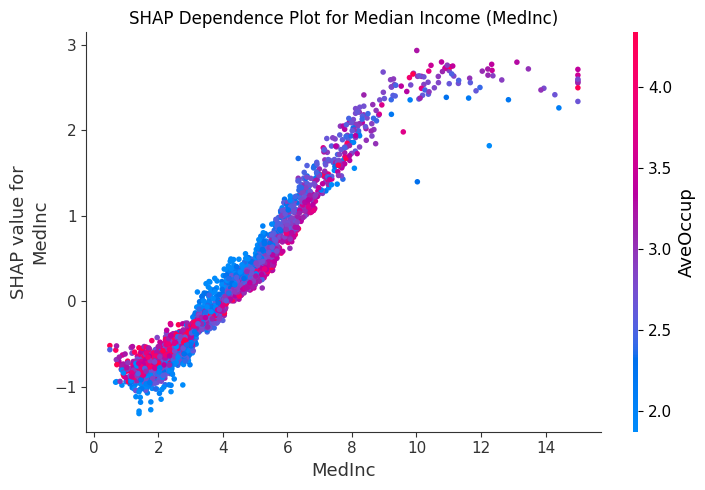

In [18]:
# Step 7:
# Plot SHAP dependence plot for the MedInc feature
shap.dependence_plot("MedInc", shap_values, X_test, show=False)
plt.title("SHAP Dependence Plot for Median Income (MedInc)")
plt.tight_layout()
plt.show()

In [19]:
medinc_position = list(X_test.columns).index("MedInc")
medinc_shap = shap_values[:, medinc_position]

medinc_analysis = pd.DataFrame({
    "MedInc": X_test["MedInc"].to_numpy(),
    "MedInc_SHAP": medinc_shap
})

spearman_medinc = medinc_analysis["MedInc"].corr(
    medinc_analysis["MedInc_SHAP"], method="spearman"
)

medinc_analysis["MedIncQuartile"] = pd.qcut(
    medinc_analysis["MedInc"],
    q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
    duplicates="drop"
)

medinc_quartiles = medinc_analysis.groupby(
    "MedIncQuartile", observed=True
).agg(
    n=("MedInc", "size"),
    mean_MedInc=("MedInc", "mean"),
    mean_SHAP=("MedInc_SHAP", "mean"),
    median_SHAP=("MedInc_SHAP", "median")
)

print(f"Spearman correlation between MedInc and its SHAP contribution: {spearman_medinc:.4f}")
display(medinc_quartiles.round(4))

Spearman correlation between MedInc and its SHAP contribution: 0.9811


,n,mean_MedInc,mean_SHAP,median_SHAP
MedIncQuartile,,,,
Q1 (lowest),1032,1.9483,-0.7183,-0.7206
Q2,1039,3.0236,-0.3801,-0.3903
Q3,1025,4.0278,0.0030,-0.0177
Q4 (highest),1032,6.3284,0.9600,0.7489


### Executed `MedInc` Dependence Interpretation and Boundary of Inference

The numerical and visual evidence show a strong, nonlinear relationship between `MedInc` and its SHAP contribution. The Spearman correlation between `MedInc` and its own SHAP value was **0.9811**, indicating a very strong monotonic association inside this fitted model. Mean `MedInc` SHAP contribution progressed from **−0.7183 in the lowest income quartile** to **−0.3801 in Q2**, approximately **0.0030 in Q3**, and **+0.9600 in the highest quartile**.

The dependence pattern rises strongly through much of the observed income range and then appears to **flatten at the highest `MedInc` values**, indicating that the Random Forest learned a nonlinear rather than purely linear income relationship. The vertical spread among observations with similar `MedInc` values also shows that income is not operating as a simple one-variable rule. The plot colors observations by `AveOccup`, which provides a visual cue about possible interaction structure, but that color pattern alone is **not a formal interaction test**.

This is one of the clearest interpretability findings in the notebook: `MedInc` is both the highest-ranked global SHAP feature and strongly directional. Even so, the result remains **predictive attribution, not causal evidence**.

**Specific next validation step:** on a reproducible subsample, compute SHAP interaction values or compare with an appropriate two-feature response analysis to determine whether the apparent `MedInc`–`AveOccup` interaction is stable rather than relying on visual inspection alone.

# 10. Local SHAP Explanations

Global averages can conceal important individual variation. Three held-out observations are selected systematically:

1. a case near the **median absolute prediction error**, rather than a hand-picked favorable example;
2. the largest **underprediction**; and
3. the largest **overprediction**.

The examples are selected by prediction-error behavior, not by whether their SHAP plots tell a preferred story. This creates a more informative local audit by including one typical case and two difficult cases.

In [20]:
sorted_error_indices = error_df["AbsoluteError"].sort_values().index
median_error_index = sorted_error_indices[len(sorted_error_indices) // 2]

largest_underprediction_index = error_df["Residual"].idxmax()
largest_overprediction_index = error_df["Residual"].idxmin()

local_cases = {
    "Typical-error case": median_error_index,
    "Largest underprediction": largest_underprediction_index,
    "Largest overprediction": largest_overprediction_index
}

local_case_rows = []
for label, idx in local_cases.items():
    local_case_rows.append({
        "Case": label,
        "Row index": idx,
        "Actual": error_df.loc[idx, "Actual"],
        "Predicted": error_df.loc[idx, "Predicted"],
        "Residual": error_df.loc[idx, "Residual"],
        "Absolute error": error_df.loc[idx, "AbsoluteError"]
    })

display(pd.DataFrame(local_case_rows).set_index("Case").round(4))

,Row index,Actual,Predicted,Residual,Absolute error
Case,,,,,
Typical-error case,14261,0.841,1.0420,-0.2010,0.2010
Largest underprediction,12069,5.000,1.9565,3.0435,3.0435
Largest overprediction,5887,0.175,3.2208,-3.0458,3.0458


Typical-error case
Actual: 0.8410 ($84,100) | Predicted: 1.0420 ($104,202) | Residual: -0.2010


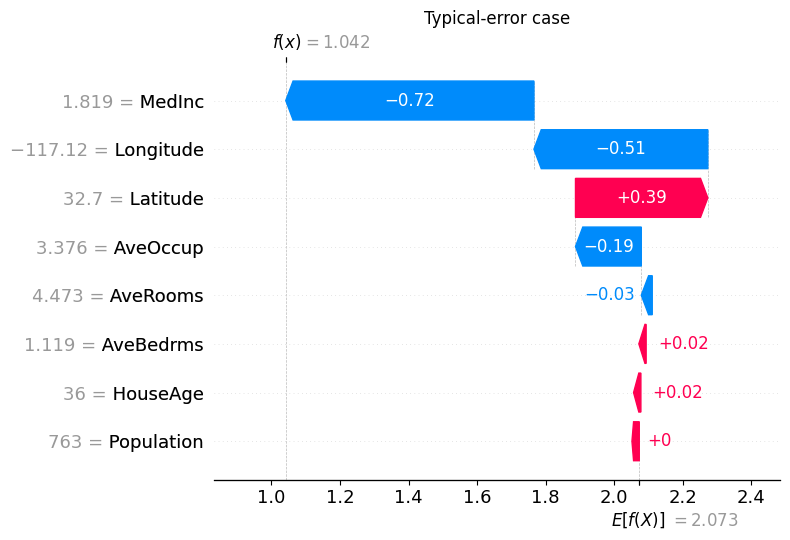

Largest underprediction
Actual: 5.0000 ($500,001) | Predicted: 1.9565 ($195,651) | Residual: 3.0435


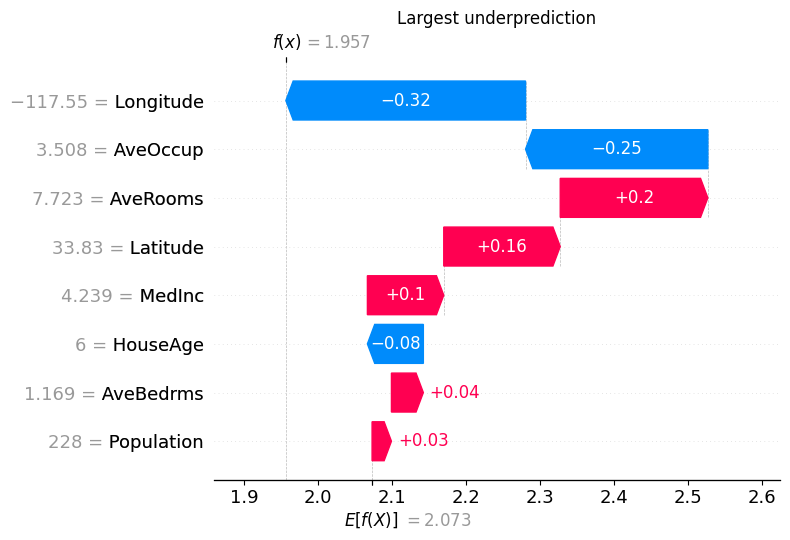

Largest overprediction
Actual: 0.1750 ($17,500) | Predicted: 3.2208 ($322,084) | Residual: -3.0458


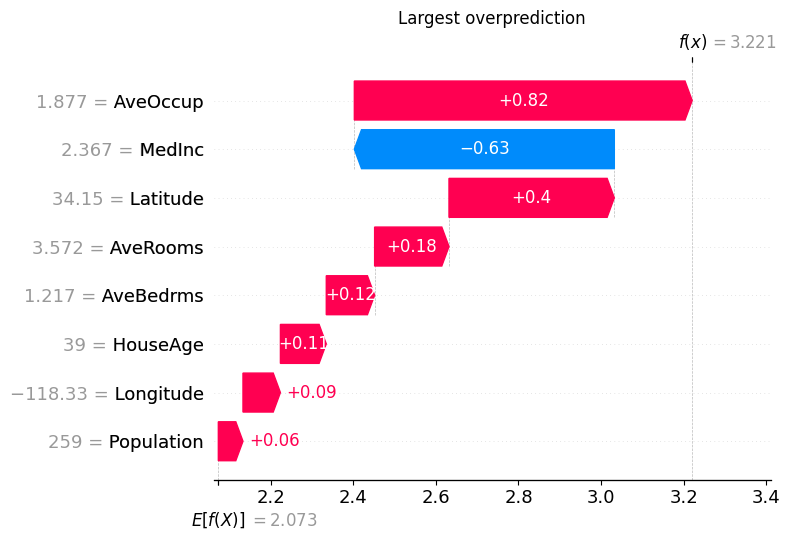

In [21]:
def plot_local_waterfall(row_index, label):
    position = X_test.index.get_loc(row_index)

    explanation = shap.Explanation(
        values=shap_values[position],
        base_values=expected_value,
        data=X_test.iloc[position].to_numpy(),
        feature_names=X_test.columns.tolist()
    )

    actual = error_df.loc[row_index, "Actual"]
    predicted = error_df.loc[row_index, "Predicted"]

    print(
        f"{label}\n"
        f"Actual: {actual:.4f} (${actual * 100000:,.0f}) | "
        f"Predicted: {predicted:.4f} (${predicted * 100000:,.0f}) | "
        f"Residual: {actual - predicted:.4f}"
    )

    shap.plots.waterfall(explanation, max_display=8, show=False)
    plt.title(label)
    plt.tight_layout()
    plt.show()

for label, idx in local_cases.items():
    plot_local_waterfall(idx, label)

### Executed Local-Explanation Interpretation

The three local cases show why SHAP explanation fidelity must be separated from prediction accuracy.

- **Typical-error case:** The actual target was **0.8410** and the Random Forest predicted **1.0420**. From the SHAP baseline of approximately **2.073**, `MedInc = 1.819` contributed about **−0.72** and `Longitude = −117.12` about **−0.51**, while `Latitude = 32.7` contributed about **+0.39**. The competing contributions moved the model well below its baseline and produced a prediction relatively close to the observed target.
- **Largest underprediction:** The actual target was **5.0000**, but the model predicted **1.9565**. `Longitude` (**−0.32**) and `AveOccup` (**−0.25**) pushed the prediction downward, while `AveRooms` (**+0.20**), `Latitude` (**+0.16**), and `MedInc` (**+0.10**) were not large enough to offset those reductions. The error was **3.0435 target units**.
- **Largest overprediction:** The actual target was **0.1750**, while the model predicted **3.2208**. `AveOccup = 1.877` contributed approximately **+0.82** and `Latitude = 34.15` about **+0.40**; `MedInc = 2.367` contributed approximately **−0.63**, but the combined positive contributions still drove the model above its baseline. The absolute error was **3.0458 target units**.

The central finding is not simply that SHAP can produce detailed local explanations. It is that SHAP can be **faithful to the model and still explain a poor prediction**. In a consequential system, local attributions should therefore be reviewed together with predictive error, model limitations, and an escalation process for anomalous or high-impact cases.

# 11. Compare SHAP With Alternative Importance Methods

To avoid treating one interpretability technique as universally preferable, three feature-importance concepts are compared:

- **SHAP mean absolute attribution** — aggregates local model-output contributions.
- **Random Forest impurity importance** — summarizes how strongly features reduce impurity across the fitted trees.
- **Permutation importance** — measures how much held-out predictive performance changes when one feature is disrupted.

The raw magnitudes are **not directly interchangeable** because these methods define importance differently. The comparison therefore emphasizes normalized patterns and rank agreement rather than treating the three numerical scales as equivalent.

In [22]:
native_importance = pd.Series(
    model.feature_importances_,
    index=X_test.columns,
    name="RF impurity importance"
)

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

permutation_series = pd.Series(
    perm.importances_mean,
    index=X_test.columns,
    name="Permutation importance"
)

shap_series = pd.Series(
    mean_abs_shap,
    index=X_test.columns,
    name="Mean |SHAP|"
)

importance_comparison = pd.concat(
    [shap_series, native_importance, permutation_series],
    axis=1
)

for col in ["Mean |SHAP|", "RF impurity importance", "Permutation importance"]:
    total = importance_comparison[col].abs().sum()
    importance_comparison[f"{col} normalized"] = (
        importance_comparison[col] / total if total != 0 else np.nan
    )

importance_comparison["SHAP rank"] = (
    importance_comparison["Mean |SHAP|"].rank(ascending=False, method="min")
)
importance_comparison["RF rank"] = (
    importance_comparison["RF impurity importance"].rank(ascending=False, method="min")
)
importance_comparison["Permutation rank"] = (
    importance_comparison["Permutation importance"].rank(ascending=False, method="min")
)

rank_cols_for_spread = ["SHAP rank", "RF rank", "Permutation rank"]
importance_comparison["Rank spread"] = (
    importance_comparison[rank_cols_for_spread].max(axis=1)
    - importance_comparison[rank_cols_for_spread].min(axis=1)
)

importance_comparison = importance_comparison.sort_values("SHAP rank")
display(importance_comparison.round(4))

,Mean |SHAP|,RF impurity importance,Permutation importance,Mean |SHAP| normalized,RF impurity importance normalized,Permutation importance normalized,SHAP rank,RF rank,Permutation rank,Rank spread
MedInc,0.5503,0.5249,0.4450,0.3809,0.5249,0.3269,1.0,1.0,1.0,0.0
Latitude,0.2608,0.0889,0.3521,0.1806,0.0889,0.2586,2.0,3.0,2.0,1.0
AveOccup,0.2376,0.1384,0.1591,0.1644,0.1384,0.1168,3.0,2.0,4.0,2.0
Longitude,0.2122,0.0886,0.2956,0.1469,0.0886,0.2172,4.0,4.0,3.0,1.0
HouseAge,0.0837,0.0546,0.0583,0.0580,0.0546,0.0429,5.0,5.0,5.0,0.0
AveRooms,0.0525,0.0443,0.0354,0.0364,0.0443,0.0260,6.0,6.0,6.0,0.0
AveBedrms,0.0280,0.0296,0.0084,0.0194,0.0296,0.0062,7.0,8.0,7.0,1.0
Population,0.0195,0.0306,0.0074,0.0135,0.0306,0.0054,8.0,7.0,8.0,1.0


,SHAP rank,RF rank,Permutation rank
SHAP rank,1.0000,0.9524,0.9762
RF rank,0.9524,1.0000,0.9048
Permutation rank,0.9762,0.9048,1.0000


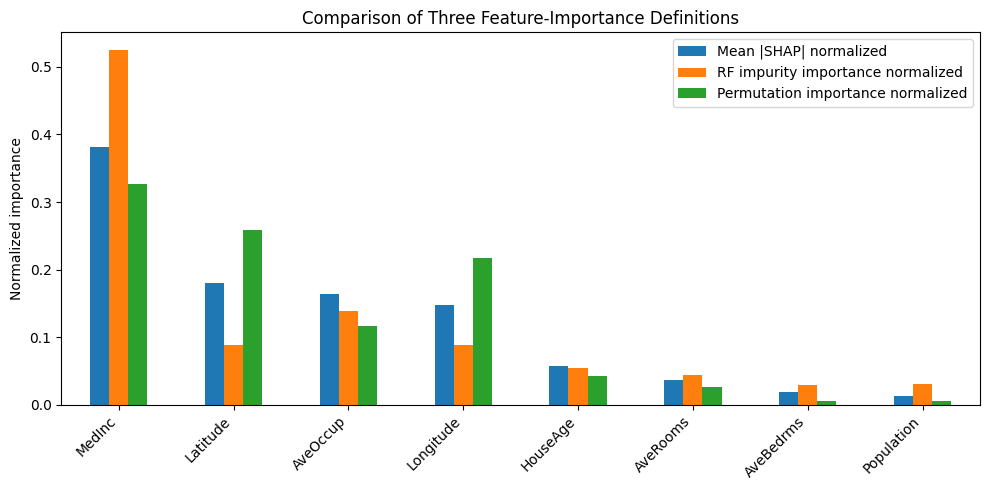

In [23]:
rank_columns = ["SHAP rank", "RF rank", "Permutation rank"]
rank_correlation = importance_comparison[rank_columns].corr(method="spearman")
display(rank_correlation.round(4))

plot_cols = [
    "Mean |SHAP| normalized",
    "RF impurity importance normalized",
    "Permutation importance normalized"
]
importance_comparison[plot_cols].plot(kind="bar", figsize=(10, 5))
plt.ylabel("Normalized importance")
plt.title("Comparison of Three Feature-Importance Definitions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Executed Method-Comparison Interpretation

The three importance methods showed strong broad agreement without producing identical rankings. Spearman rank correlation was **0.9762 between SHAP and permutation importance**, **0.9524 between SHAP and Random Forest impurity importance**, and **0.9048 between impurity and permutation importance**.

All three methods ranked `MedInc` first. SHAP ranked `Latitude` second, `AveOccup` third, and `Longitude` fourth. Permutation importance placed `Longitude` third and `AveOccup` fourth, while the native Random Forest measure placed `AveOccup` second and `Latitude` third. The largest disagreement involved `AveOccup`, with a **two-position rank spread**.

This supports a narrow robustness conclusion: the main global importance structure is similar across the three definitions, particularly the dominance of `MedInc`, but the exact ordering of secondary features depends on what "importance" means. SHAP aggregates attributed prediction contributions, permutation importance measures performance loss after feature disruption, and impurity importance reflects tree-split usage.

For this case study, SHAP is especially useful because one framework supports both global ranking and signed local explanations. The remaining rank differences also motivate the feature-dependence audit that follows, because correlated predictors can complicate any claim that one ranking is uniquely correct.

# 12. Feature Dependence Audit

Feature dependence matters because attribution methods must define what it means for a feature to be absent or unknown. Aas et al. (2021) show that dependence among features can materially affect Shapley-style explanations.

This section does not attempt to "correct" the executed SHAP values. Instead, it tests whether dependence is an empirical condition that should limit how confidently attribution is assigned to individual features. Pearson correlation is used as a transparent first check, but it captures **linear association only**; lower Pearson correlation does not rule out nonlinear or more complex dependence.

In [24]:
feature_corr = X_train.corr(method="pearson")

upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
corr_pairs = (
    feature_corr.where(upper_mask)
    .stack()
    .rename("Correlation")
    .reset_index()
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2"})
)
corr_pairs["Absolute correlation"] = corr_pairs["Correlation"].abs()
corr_pairs = corr_pairs.sort_values("Absolute correlation", ascending=False)

print("Strongest observed linear feature correlations in the training set:")
display(corr_pairs.head(10).round(4))

Strongest observed linear feature correlations in the training set:


,Feature 1,Feature 2,Correlation,Absolute correlation
27,Latitude,Longitude,-0.9245,0.9245
13,AveRooms,AveBedrms,0.8362,0.8362
1,MedInc,AveRooms,0.3360,0.3360
9,HouseAge,Population,-0.2923,0.2923
7,HouseAge,AveRooms,-0.1609,0.1609
0,MedInc,HouseAge,-0.1217,0.1217
16,AveRooms,Latitude,0.1107,0.1107
23,Population,Latitude,-0.1025,0.1025
12,HouseAge,Longitude,-0.1018,0.1018
24,Population,Longitude,0.0943,0.0943


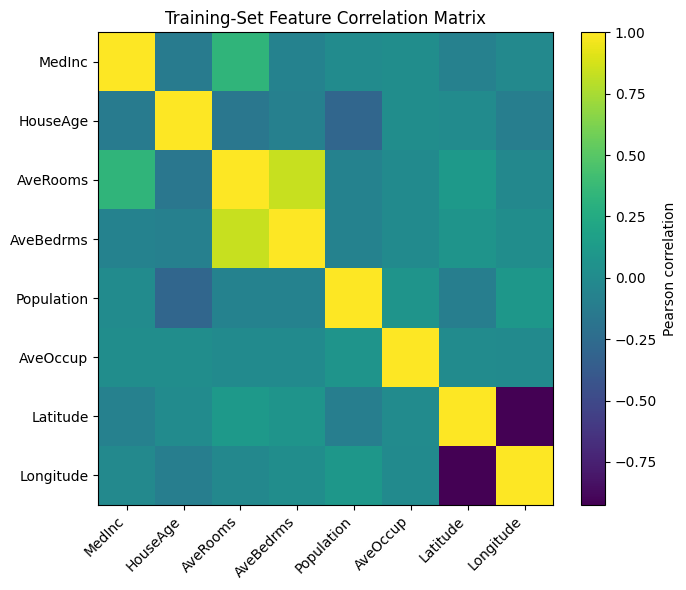

In [25]:
plt.figure(figsize=(7, 6))
im = plt.imshow(feature_corr, aspect="auto")
plt.colorbar(im, label="Pearson correlation")
plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(feature_corr.index)), feature_corr.index)
plt.title("Training-Set Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Executed Feature-Dependence Interpretation

The strongest observed training-set correlation was between **`Latitude` and `Longitude` (r = −0.9245)**, followed by **`AveRooms` and `AveBedrms` (r = 0.8362)**. These are substantial linear relationships. The geographic pair is especially important because both variables also ranked among the most influential SHAP features.

This does not make the SHAP results unusable, but it limits how confidently attribution can be interpreted as uniquely belonging to one correlated feature. When predictors contain overlapping information, credit can be distributed differently depending on the fitted model and the explainer's treatment of dependence. The executed TreeExplainer reported **`tree_path_dependent`**, so the attribution semantics should be understood in that context.

Because the audit is based on Pearson correlation, it should also be treated as a **screen rather than a complete dependence analysis**. Nonlinear dependence could remain even where the reported linear correlations are modest.

**Specific next validation step:** compare the current explanations with a carefully specified alternative SHAP dependence formulation using defensible background data, then test whether the global rankings and consequential local explanations materially change.

# 13. Explanation Robustness Across Random-Forest Seeds

Fixing `random_state=42` makes the primary model reproducible, but reproducibility does not by itself show that the explanation pattern is insensitive to the Random Forest's internal randomization.

As a focused robustness test, three Random Forests with different seeds are trained on the **same training split**. Predictive performance is evaluated on the full test set, while global mean absolute SHAP importance is calculated on the same fixed **1,000-observation test subsample** for each seed. This isolates **algorithmic-seed stability**; it does not test stability across different data samples, time periods, geographic regions, or model families.

In [26]:
stability_seeds = [7, 42, 101]
stability_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=2026
)

stability_importance = {}
stability_performance_rows = []

for seed in stability_seeds:
    seed_model = RandomForestRegressor(
        n_estimators=100,
        random_state=seed
    )
    seed_model.fit(X_train, y_train)

    seed_pred = seed_model.predict(X_test)
    mae, rmse, r2 = regression_metrics(y_test, seed_pred)
    stability_performance_rows.append({
        "Seed": seed,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    seed_explainer = shap.TreeExplainer(seed_model)
    seed_shap = np.asarray(
        seed_explainer.shap_values(stability_sample)
    )
    stability_importance[f"Seed {seed}"] = np.abs(seed_shap).mean(axis=0)

stability_performance = pd.DataFrame(stability_performance_rows).set_index("Seed")
stability_importance = pd.DataFrame(
    stability_importance,
    index=X_test.columns
)

display(stability_performance.round(4))
display(stability_importance.round(4))

,MAE,RMSE,R²
Seed,,,
7,0.3284,0.5057,0.8048
42,0.3275,0.5053,0.8051
101,0.3261,0.5033,0.8067


,Seed 7,Seed 42,Seed 101
MedInc,0.5643,0.5620,0.5595
HouseAge,0.0845,0.0836,0.0823
AveRooms,0.0521,0.0545,0.0540
AveBedrms,0.0288,0.0281,0.0283
Population,0.0208,0.0203,0.0207
AveOccup,0.2364,0.2362,0.2331
Latitude,0.2597,0.2612,0.2636
Longitude,0.2028,0.2023,0.2045


In [27]:
stability_ranks = stability_importance.rank(
    ascending=False,
    method="min"
)

stability_rank_corr = stability_ranks.corr(method="spearman")

print("SHAP global-importance ranks by seed:")
display(stability_ranks.astype(int))

print("\nSpearman correlations among seed-specific SHAP rankings:")
display(stability_rank_corr.round(4))

SHAP global-importance ranks by seed:


,Seed 7,Seed 42,Seed 101
MedInc,1,1,1
HouseAge,5,5,5
AveRooms,6,6,6
AveBedrms,7,7,7
Population,8,8,8
AveOccup,3,3,3
Latitude,2,2,2
Longitude,4,4,4



Spearman correlations among seed-specific SHAP rankings:


,Seed 7,Seed 42,Seed 101
Seed 7,1.0,1.0,1.0
Seed 42,1.0,1.0,1.0
Seed 101,1.0,1.0,1.0


### Executed Robustness Interpretation

The three Random Forest seeds produced very similar held-out performance: RMSE ranged from **0.5033 to 0.5057**, and R² ranged from **0.8048 to 0.8067**. On the fixed 1,000-observation SHAP subsample, the global feature ranks were **identical across seeds 7, 42, and 101**, with every pairwise Spearman rank correlation equal to **1.0000**.

The importance **magnitudes were not identical**—for example, mean |SHAP| for `MedInc` ranged from **0.5595 to 0.5643**—but the ordering did not change. This distinction matters: the experiment supports stability of the **ranking** under the tested seeds more strongly than invariance of the exact attribution magnitudes.

The conclusion remains narrow. All three models used the same dataset, same 80/20 split, same model class, same 100-tree specification, same fixed SHAP subsample, and the same explanation framework. The experiment does **not** establish stability across resampled datasets, geographic holdouts, time periods, alternative model families, or different SHAP dependence assumptions.

# 14. Transparency, Interpretability, and Real-World Decision-Making

Explainability is most valuable when model outputs affect decisions that require review, accountability, debugging, or stakeholder understanding. SHAP is useful in these settings because the same framework can support **local explanations for individual predictions** and **global summaries across many predictions** (Lundberg & Lee, 2017; Lundberg et al., 2020). NIST's explainable-AI principles also distinguish merely producing an explanation from ensuring that it is meaningful, accurately reflects the system, and operates within declared knowledge limits (Phillips et al., 2021).

### Scenarios Where SHAP Is Particularly Useful

| Scenario | Why SHAP can help | Important boundary |
|---|---|---|
| **Credit or financial risk review** | Local attributions can show which model inputs pushed one prediction above or below the baseline; global summaries can support model-risk review | Attribution is not causal recourse and should not replace fairness, adverse-action, or regulatory analysis |
| **Clinical risk modeling** | Clinicians can inspect which variables drove a risk score before incorporating it into professional judgment | Explanation does not establish medical causation or justify autonomous treatment decisions |
| **Housing or appraisal-model auditing** | Global and local explanations can reveal reliance on geography, income, or possible proxy variables | Geographic attribution can intersect with fairness and legal concerns; separate compliance and fairness analysis is required |
| **Fraud or anomaly investigation** | Case-level explanations can help reviewers understand why a transaction or account was flagged | Unusual cases can be legitimate, and a faithful explanation can still describe a false positive |

### Concrete Governance Safeguards

| Risk | Safeguard | Responsible role |
|---|---|---|
| Poor model performance | Baseline comparison, cross-validation, appropriate geographic holdouts, and predefined error tolerances | Model-development team and independent validation/model-risk function |
| SHAP misread as causation | Label attributions as model-behavior explanations and prohibit causal language without causal identification | Model owner, domain expert, and governance reviewer |
| Unstable explanations | Monitor explanation stability across retraining, seeds, time, and relevant subgroups | Model owner / MLOps |
| Correlated or proxy features | Audit dependence and proxy risk; compare attribution formulations when conclusions are consequential | Data science, fairness/compliance, and domain reviewers |
| Hidden fairness concerns | Conduct a separate fairness assessment with appropriate protected-group and outcome data | Fairness, legal, and compliance functions |
| Automation bias | Require trained human review and escalation for high-impact or anomalous cases | Decision owner / domain reviewer |
| Weak traceability | Log model version, inputs, prediction, explanation configuration, review action, and override reason | MLOps and governance |
| Data or model drift | Monitor feature distributions, predictive error, and explanation distributions after deployment | Model owner / monitoring team |
| Stakeholder misunderstanding | Test explanation formats with intended users and document known limitations | Product/domain owner and governance |

### Operational Reality

TreeExplainer is computationally efficient for supported tree models, but explanation generation still adds processing, storage, monitoring, and review requirements. In high-volume applications, global diagnostics may be produced periodically while local explanations are generated for consequential or escalated cases. In genuinely high-stakes decisions, explanation latency should not be reduced by removing validation or human review simply to make the system faster.

### Housing-Specific Boundary

This notebook uses aggregated 1990 census-era block-group data, a random train/test split, and an academic model—not a contemporary property-appraisal dataset or validated decision system. It therefore provides an **academic demonstration of explainability**, not evidence that this model should be used for mortgage, appraisal, pricing, eligibility, or legal decisions. Fairness is also **not evaluated** here because the data and study design required for a valid fairness assessment are outside this project.

**Practical takeaway:** SHAP is most defensible when it is embedded in a broader review and governance process, not when a plot or attribution is treated as stand-alone proof that a model decision is correct.

# 15. Advantages, Limitations, and Suitability of SHAP

## Advantages

1. **Local and global analysis:** individual attributions can be aggregated to reveal broader model patterns.
2. **Signed additive contributions:** SHAP shows whether features push a model output above or below a reference value.
3. **Theoretical grounding:** SHAP connects model explanations to Shapley-value principles from cooperative game theory (Shapley, 1953; Lundberg & Lee, 2017).
4. **Tree efficiency:** TreeExplainer is particularly suitable for supported tree ensembles such as the primary Random Forest (Lundberg et al., 2020).
5. **Audit value:** explanations can help identify unexpected model dependencies, individual prediction drivers, and changes in model behavior.

## Limitations and Challenges

1. **Model dependence:** SHAP explains the fitted model, so an inaccurate, misspecified, or biased model can still have internally coherent explanations.
2. **No causal guarantee:** attribution should not be interpreted as the effect of intervening on a feature.
3. **Feature dependence:** correlated predictors can complicate how credit is allocated and how absent features are represented (Aas et al., 2021).
4. **Explainer/configuration dependence:** background distributions and perturbation assumptions can change attribution semantics.
5. **Computational cost:** model-agnostic SHAP approaches can be expensive; TreeExplainer reduces this burden for supported tree models.
6. **Communication risk:** a technically faithful explanation can still be misunderstood by decision-makers or affected individuals.
7. **Robustness/security limits:** Slack et al. (2020) demonstrated that certain post-hoc explanation setups involving LIME and SHAP can be manipulated under adversarial conditions. Explanations should therefore be treated as audit evidence, not as a stand-alone guarantee of trustworthiness.

### Why SHAP Is Suitable Here

SHAP is well matched to this project because the primary Random Forest is nonlinear and less intrinsically transparent than a simple linear model. TreeExplainer efficiently decomposes its predictions, while the resulting attributions support global ranking, directional analysis, dependence analysis, and local case explanations. Its suitability is therefore **method-to-model specific**, not a claim that SHAP is universally preferable.

### Method Suitability Comparison

| Method | Best suited for | Main trade-off relative to SHAP in this notebook |
|---|---|---|
| **Intrinsically interpretable model** | Decisions where direct model transparency is a primary requirement and predictive performance remains adequate | May not capture the same nonlinear structure as the Random Forest |
| **Permutation importance** | Model-agnostic global importance based on held-out performance | Does not provide signed, additive local explanations |
| **LIME** | Local surrogate explanations when SHAP is unavailable or impractical | Sampling and locality choices can affect explanation stability (Ribeiro et al., 2016) |
| **Partial dependence** | Average model-response patterns for selected features | Describes response behavior rather than allocating an individual prediction among features |
| **SHAP / TreeExplainer** | Combined global and local explanation of supported tree models | Requires careful interpretation of baselines, feature dependence, and attribution assumptions |

The method choice should therefore follow the **decision question, model class, feature-dependence structure, explanation audience, computational budget, and validation requirements** rather than a preference for one explainability tool.

# 16. Integrated Executed-Evidence Summary

The following executed cell consolidates the notebook's most important quantitative findings directly from the stored variables. Keeping this evidence record next to the synthesis reduces the risk that later narrative claims drift away from the actual model outputs.

One formatting detail is worth noting: the summary cell rounds the maximum SHAP reconstruction error to eight decimal places, so it displays as **0.00000000**. Section 7.1 reports the unrounded executed maximum as approximately **$2.21 \times 10^{-13}$**, which is effectively zero at ordinary numerical precision.

In [28]:
cv_rf = cv_results[cv_results["Model"] == "Random Forest"]
top_feature = shap_importance.iloc[0]
second_feature = shap_importance.iloc[1]

max_pair = corr_pairs.iloc[0]
off_diag_stability = stability_rank_corr.to_numpy()[
    ~np.eye(stability_rank_corr.shape[0], dtype=bool)
]
min_stability_corr = np.nanmin(off_diag_stability)

summary_md = f"""
### Executed Evidence Summary

**Predictive evidence**
- Held-out Random Forest: **MAE = {rf_mae:.4f}** (${rf_mae*100000:,.0f}), **RMSE = {rf_rmse:.4f}** (${rf_rmse*100000:,.0f}), **R² = {rf_r2:.4f}**.
- Mean baseline: **RMSE = {dummy_rmse:.4f}**, **R² = {dummy_r2:.4f}**.
- Linear Regression: **RMSE = {linear_rmse:.4f}**, **R² = {linear_r2:.4f}**.
- Five-fold training-set CV for Random Forest: **mean RMSE = {cv_rf['RMSE'].mean():.4f} ± {cv_rf['RMSE'].std():.4f}**, **mean R² = {cv_rf['R²'].mean():.4f} ± {cv_rf['R²'].std():.4f}**.

**SHAP fidelity and global attribution**
- Explainer baseline: **{expected_value:.4f}** (about **${expected_value*100000:,.0f}** in target units).
- Maximum SHAP reconstruction error: **{reconstruction_error.max():.8f}**.
- Highest mean absolute SHAP feature: **{top_feature['Feature']}**, mean |SHAP| = **{top_feature['Mean |SHAP|']:.4f}**.
- Second-highest: **{second_feature['Feature']}**, mean |SHAP| = **{second_feature['Mean |SHAP|']:.4f}**.
- `MedInc` value vs. `MedInc` SHAP contribution Spearman correlation: **{spearman_medinc:.4f}**.

**Dependence and robustness**
- Strongest observed training-set feature correlation: **{max_pair['Feature 1']} vs. {max_pair['Feature 2']}**, r = **{max_pair['Correlation']:.4f}**.
- Lowest pairwise Spearman correlation among the three seed-specific global SHAP rankings: **{min_stability_corr:.4f}**.

**Boundary of inference**
These results describe the primary Random Forest, this dataset, this split, and the executed SHAP configuration. They do **not** establish causal housing determinants, current-market validity, fairness, or deployment readiness.
"""

display(Markdown(summary_md))


### Executed Evidence Summary

**Predictive evidence**
- Held-out Random Forest: **MAE = 0.3275** (\$32,754), **RMSE = 0.5053** (\$50,534), **R² = 0.8051**.
- Mean baseline: **RMSE = 1.1449**, **R² = -0.0002**.
- Linear Regression: **RMSE = 0.7456**, **R² = 0.5758**.
- Five-fold training-set CV for Random Forest: **mean RMSE = 0.5111 ± 0.0128**, **mean R² = 0.8045 ± 0.0068**.

**SHAP fidelity and global attribution**
- Explainer baseline: **2.0731** (about **\$207,307** in target units).
- Maximum SHAP reconstruction error: **0.00000000**.
- Highest mean absolute SHAP feature: **MedInc**, mean |SHAP| = **0.5503**.
- Second-highest: **Latitude**, mean |SHAP| = **0.2608**.
- `MedInc` value vs. `MedInc` SHAP contribution Spearman correlation: **0.9811**.

**Dependence and robustness**
- Strongest observed training-set feature correlation: **Latitude vs. Longitude**, r = **-0.9245**.
- Lowest pairwise Spearman correlation among the three seed-specific global SHAP rankings: **1.0000**.

**Boundary of inference**
These results describe the required Random Forest, this dataset, this split, and the executed SHAP configuration. They do **not** establish causal housing determinants, current-market validity, fairness, or deployment readiness.


# 17. Final Analytical Synthesis

The executed evidence supports three main conclusions.

First, the primary Random Forest provided a defensible model to explain **within this experiment**. On the held-out test set it achieved **RMSE = 0.5053 and R² = 0.8051**, outperforming both the mean baseline and Linear Regression. Five-fold training-set cross-validation was similar (**mean RMSE = 0.5111 ± 0.0128; mean R² = 0.8045 ± 0.0068**). Performance was not uniform, however: the highest target quartile had the largest error (**MAE = 0.5401**) and was underpredicted on average. Model quality therefore needs to be interpreted by error pattern as well as by overall metrics.

Second, SHAP provided internally faithful and analytically informative explanations of the fitted Random Forest. The maximum reconstruction error was approximately **$2.21 \times 10^{-13}$**, showing that the additive attributions reproduced the model output to numerical precision. Globally, `MedInc` was the dominant SHAP feature (**38.09% of total mean absolute attribution**), and its value had a **0.9811 Spearman correlation with its own SHAP contribution**. The local cases added an important limitation: SHAP clearly explained both the largest underprediction and largest overprediction even though each prediction was wrong by more than **3.04 target units**. Explanation fidelity therefore did not imply prediction correctness.

Third, the broad explanation pattern was robust under the limited checks performed, but important boundaries remain. SHAP and permutation-importance ranks correlated **0.9762**, and SHAP and native tree-importance ranks correlated **0.9524**. On the fixed 1,000-observation robustness subsample, global SHAP ranks were identical across the three tested Random Forest seeds (**pairwise Spearman = 1.0000**), although the attribution magnitudes varied slightly. At the same time, `Latitude` and `Longitude` were strongly correlated (**r = −0.9245**), and `AveRooms` and `AveBedrms` were also strongly correlated (**r = 0.8362**), so unique attribution to correlated predictors should be interpreted cautiously.

### What This Experiment Supports

- A reproducible evaluation of the primary Random Forest.
- Global and local SHAP explanations of the fitted model.
- Direct testing of SHAP additivity for the executed model output.
- Comparison of multiple feature-importance definitions.
- A limited robustness assessment across Random Forest seeds.
- Evidence-based discussion of prediction error, feature dependence, governance, and interpretive limits.

### What This Experiment Does Not Support

- Causal claims about why California housing values change.
- A claim that the Random Forest is the best possible predictive model.
- A claim that the 1990 census-based dataset represents the current California housing market.
- A fairness conclusion.
- A claim that mathematically faithful SHAP explanations make individual predictions correct.
- A recommendation to deploy this model in consequential housing, finance, healthcare, or legal decisions.

### Specific Next-Validation Plan

A stronger follow-up study would:

1. repeat predictive evaluation with **multiple resamples and geographically separated holdouts**;
2. compare additional model families to determine whether the explanatory conclusions are model-specific;
3. test SHAP stability across retraining, time, and alternative dependence formulations using defensible background data;
4. investigate the apparent `MedInc` interaction pattern with a formal interaction analysis rather than visual inspection alone; and
5. conduct appropriate subgroup/fairness analysis and stakeholder comprehension testing before any consequential application.

**Overall conclusion:** SHAP made the Random Forest's prediction logic substantially more inspectable at both global and local levels, but its value was greatest when combined with predictive validation, error analysis, robustness checks, and explicit governance boundaries. Explainability strengthened model auditing; it did not replace model validation, causal analysis, fairness assessment, or human oversight.

# 18. Engineering Takeaways

This case study demonstrates that **explainability and model quality are related but separate responsibilities**. The Random Forest performed substantially better than the two simple comparison models, and its held-out metrics were close to the five-fold cross-validation results. At the same time, the error analysis showed that performance was not uniform: the highest target quartile had the largest errors and was underpredicted on average. What stood out most was that SHAP could reconstruct and explain the two most extreme prediction errors with near-perfect additive fidelity even though both predictions were still wrong by more than three target units. That made the limitation concrete: transparency can help diagnose a model, but it cannot substitute for accuracy.

The feature-attribution results also demonstrated why interpretability requires more than reading one importance plot. `MedInc` was consistently the strongest feature, accounted for the largest share of global SHAP magnitude, and showed a very strong positive monotonic association with its own SHAP contribution. However, the analysis also identified strong dependence between `Latitude` and `Longitude` and between `AveRooms` and `AveBedrms`. High agreement among SHAP, permutation importance, native tree importance, and the three seed-specific SHAP rankings increases confidence in the **broad model pattern**, but it does not turn those attributions into causal effects or uniquely correct allocations of importance.

The most important lesson from the notebook is that responsible explainability requires a chain of evidence: validate the model, inspect where it fails, test explanation fidelity and stability, compare interpretability methods, identify dependence assumptions, and communicate clear limits. If this work were extended beyond an academic demonstration, I would prioritize geographically separated validation, current and representative data, comparison across additional model families, alternative SHAP dependence formulations, formal testing of apparent interaction patterns, and stakeholder evaluation of whether the explanations are actually understandable and decision-relevant. In a high-stakes application, I would also require separate fairness analysis, continuous monitoring, human review, and documented escalation rather than treating SHAP as a stand-alone trust mechanism.

# 19. References

Aas, K., Jullum, M., & Løland, A. (2021). Explaining individual predictions when features are dependent: More accurate approximations to Shapley values. *Artificial Intelligence, 298*, 103502. https://doi.org/10.1016/j.artint.2021.103502

Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N., & Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence, 2*(1), 56–67. https://doi.org/10.1038/s42256-019-0138-9

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*, 4765–4774. https://papers.neurips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions

Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. *Statistics & Probability Letters, 33*(3), 291–297. https://doi.org/10.1016/S0167-7152(96)00140-X

Phillips, P. J., Hahn, C. A., Fontana, P. C., Yates, A. N., Greene, K. K., Broniatowski, D. A., & Przybocki, M. A. (2021). *Four principles of explainable artificial intelligence* (NISTIR 8312). National Institute of Standards and Technology. https://doi.org/10.6028/NIST.IR.8312

Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 1135–1144). Association for Computing Machinery. https://doi.org/10.1145/2939672.2939778

Scikit-learn developers. (n.d.). *California housing dataset*. Scikit-learn. Retrieved August 30, 2026, from https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

Shapley, L. S. (1953). A value for n-person games. In H. W. Kuhn & A. W. Tucker (Eds.), *Contributions to the theory of games* (Vol. 2, pp. 307–317). Princeton University Press.

Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2020). Fooling LIME and SHAP: Adversarial attacks on post hoc explanation methods. In *Proceedings of the AAAI/ACM Conference on AI, Ethics, and Society* (pp. 180–186). Association for Computing Machinery. https://doi.org/10.1145/3375627.3375830